# **Optimization Project 2**

### Group 15: Nandini Anand Kumar, Maria-Laura Peña, Prisca Varner, Suparna Swaroop

# Airline Revenue Management using Dynamic Programming

---

## Problem Description

We model airline ticket pricing as a stochastic dynamic programming problem over a booking horizon of 365 days.

The airline sells two types of tickets:
- Coach class (base capacity = 100, with overbooking allowed)
- First-class (capacity = 20)

At each day, the airline must decide the ticket prices in order to **maximize expected discounted profit**, while accounting for:
- uncertain customer demand,
- time value of money,
- and overbooking penalties.


## Mathematical Formulation

We define the value function:

\[
V(t, c, f)
\]

as the maximum expected discounted profit from day \( t \) onward, given:
- \( t \): days remaining (0 to 365)
- \( c \): number of coach tickets sold
- \( f \): number of first-class tickets sold



## Decision Variables

At each day, the airline chooses:

- Coach price:
$$
p_c \in \{300, 325, 350\}
$$

- First-class price:
$$
p_f \in \{425, 500\}
$$



## Demand Model

Ticket sales are probabilistic:

- Coach sale probability:
$$
P_c(p_c)
$$

- First-class sale probability:
$$
P_f(p_f)
$$

Additionally, when first-class is full:

$$
P_c(p_c) \leftarrow P_c(p_c) + 0.04
$$

This captures spillover demand from first-class to coach.



## State Transitions

Each day, four outcomes are possible:

- No sale:
$$
(1 - P_c)(1 - P_f)
$$

- Coach only:
$$
P_c(1 - P_f)
$$

- First only:
$$
(1 - P_c)P_f
$$

- Both:
$$
P_c P_f
$$

State updates:

$$
c' = c + \text{coach sale}
$$

$$
f' = f + \text{first-class sale}
$$



## Bellman Equation

$$
V(t, c, f) =
\max_{p_c, p_f}
\mathbb{E} \left[
\text{Revenue} + \delta \cdot V(t+1, c', f')
\right]
$$

where:

$$
\delta = \frac{1}{1 + \frac{0.17}{365}}
$$


is the discount factor.

## Terminal Condition (t = 365):
At departure, no revenue — only overbooking cost.

We compute:

V(365, c, f) = - E[overbooking cost]

This is computed using binomial distributions:
- Coach show-up probability = 0.95
- First-class show-up probability = 0.97


# **Task 1**

### What is the expected discounted profit of selling these tickets and paying out overbooking costs over the course of the year?






## Objective

Determine the optimal pricing policy over time to maximize expected discounted profit.


##  Overbooking Cost Model

Passenger show-up follows binomial distributions:

$$
C_{\text{show}} \sim \text{Binomial}(c, 0.95)
$$

$$
F_{\text{show}} \sim \text{Binomial}(f, 0.97)
$$

If coach passengers exceed capacity:

$$
\text{overflow} = \max(C_{\text{show}} - 100, 0)
$$

Then:
- Some passengers are upgraded (cost = 50)
- Remaining passengers are denied boarding (cost = 425)

Expected cost:

$$
\mathbb{E}[\text{cost}] =
\sum_{c_s} \sum_{f_s}
P(c_s, f_s) \cdot \text{cost}(c_s, f_s)
$$


## Solution Approach

We solve using **backward dynamic programming**:

1. Compute terminal costs  
2. Iterate backward from day 364 to 0  
3. Evaluate all pricing combinations  
4. Choose the action that maximizes expected value  





In [1]:
import numpy as np
from scipy.stats import binom
from math import comb

In [2]:
# ---------------- PARAMETERS ----------------
T = 365
COACH_CAPACITY = 100
FIRST_CAPACITY = 20

COACH_SHOW_PROB = 0.95
FIRST_SHOW_PROB = 0.97

BUMP_COST = 50
DENIED_COST = 425

DELTA = 1 / (1 + 0.17 / 365)

COACH_ACTIONS = [(300, 0.65), (325, 0.45), (350, 0.30)]
FIRST_ACTIONS = [(425, 0.08), (500, 0.04)]

# ---------------- BINOMIAL ----------------
def binom_pmf(n, k, p):
    return comb(n, k) * (p**k) * ((1-p)**(n-k))

# ---------------- TERMINAL COST ----------------
def expected_terminal_cost(max_c):
    cost_table = np.zeros((max_c+1, FIRST_CAPACITY+1))

    for c in range(max_c+1):
        for f in range(FIRST_CAPACITY+1):

            expected_cost = 0

            for c_show in range(c+1):
                pc = binom_pmf(c, c_show, COACH_SHOW_PROB)

                overflow = max(c_show - COACH_CAPACITY, 0)
                if overflow == 0:
                    continue

                for f_show in range(f+1):
                    pf = binom_pmf(f, f_show, FIRST_SHOW_PROB)

                    open_first = max(FIRST_CAPACITY - f_show, 0)

                    bumped = min(overflow, open_first)
                    denied = overflow - bumped

                    cost = BUMP_COST * bumped + DENIED_COST * denied

                    expected_cost += pc * pf * cost

            cost_table[c, f] = expected_cost

    return cost_table


# ---------------- DP SOLVER ----------------
def solve_dp(coach_limit):

    V = np.zeros((T+1, coach_limit+1, FIRST_CAPACITY+1))
    policy = np.empty((T, coach_limit+1, FIRST_CAPACITY+1), dtype=object)

    # terminal
    term_cost = expected_terminal_cost(coach_limit)
    V[T] = -term_cost

    # backward DP
    for t in range(T-1, -1, -1):
        for c in range(coach_limit+1):
            for f in range(FIRST_CAPACITY+1):

                best = -1e18
                best_action = None

                for cp, cq in COACH_ACTIONS:
                    for fp, fq in FIRST_ACTIONS:

                        # +4% rule
                        p_coach = cq
                        if f == FIRST_CAPACITY:
                            p_coach = min(p_coach + 0.04, 1.0)

                        # no sales if full
                        if c >= coach_limit:
                            p_coach = 0.0
                        if f >= FIRST_CAPACITY:
                            fq = 0.0

                        val = 0

                        # all outcomes
                        for sc in [0,1]:
                            for sf in [0,1]:

                                prob = (
                                    (p_coach if sc else (1 - p_coach)) *
                                    (fq if sf else (1 - fq))
                                )

                                if prob == 0:
                                    continue

                                c_new = min(c + sc, coach_limit)
                                f_new = min(f + sf, FIRST_CAPACITY)

                                revenue = sc * cp + sf * fp

                                val += prob * (revenue + DELTA * V[t+1, c_new, f_new])

                        if val > best:
                            best = val
                            best_action = (cp, fp)

                V[t, c, f] = best
                policy[t, c, f] = best_action

    return V, policy

In [3]:
V, policy = solve_dp(105)

In [4]:
optimal_profit = V[0,0,0]

print("========== TASK 1 RESULTS ==========")
print(f"Optimal expected discounted profit: ${optimal_profit:,.2f}")
print("------------------------------------")

# Value insights
print("Sample Value Function Insights:")
print(f"Value at start (t=0, c=0, f=0): ${V[0,0,0]:,.2f}")
print(f"Value near end (t=360, c=50, f=10): ${V[360,50,10]:,.2f}")
print(f"Terminal value (t=365, c=102, f=19): ${V[365,102,19]:,.2f}")
print("------------------------------------")

# Overbooking example
c_test, f_test = 102, 19
terminal_cost = -V[365, c_test, f_test]

print("Overbooking Impact Example:")
print(f"Expected overbooking cost at (c={c_test}, f={f_test}): ${terminal_cost:,.2f}")
print("------------------------------------")

# Pricing Policy
print("Policy Insight:")
best_coach_price, best_first_price = policy[0,0,0]

print(f"Optimal Day-0 coach price: ${best_coach_price}")
print(f"Optimal Day-0 first-class price: ${best_first_price}")
print("====================================")

========== TASK 1 RESULTS ==========
Optimal expected discounted profit: $41,909.75
------------------------------------
Sample Value Function Insights:
Value at start (t=0, c=0, f=0): $41,909.75
Value near end (t=360, c=50, f=10): $1,143.93
Terminal value (t=365, c=102, f=19): $-3.09
------------------------------------
Overbooking Impact Example:
Expected overbooking cost at (c=102, f=19): $3.09
------------------------------------
Policy Insight:
Optimal Day-0 coach price: $350
Optimal Day-0 first-class price: $425


## Result

$$
V(0,0,0) \approx 41{,}909
$$

This represents the **maximum expected discounted profit** under the optimal pricing strategy.



## Key Insights

- Early in the booking horizon → higher prices (low urgency)
- Later → prices decrease to fill remaining seats
- The model balances revenue and risk dynamically



# **Task 2**
### Which overbooking policy from this leads to the largest profits by the airline?


# Optimal Overbooking Level



## Objective

Evaluate how different overbooking levels affect expected profit.

We define:

$$
\text{Capacity} = 100 + x, \quad x \in \{5,6,...,20\}
$$



## Approach

For each overbooking level \( x \):

1. Solve the dynamic program  
2. Compute:
$$
V_x(0,0,0)
$$

3. Compare profits across all values of \( x \)



## Optimization Problem

$$
\max_{x \in [5,20]} V_x(0,0,0)
$$



In [5]:
print("\n========== TASK 2 RESULTS ==========\n")

results = {}

# Loop over overbooking levels (5 to 20)
for overbook in range(5, 21):

    coach_limit = COACH_CAPACITY + overbook

    print(f"Running DP for overbooking level = {overbook} (capacity = {coach_limit})...")

    V, _ = solve_dp(coach_limit)

    profit = V[0,0,0]
    results[overbook] = profit

    print(f"  → Expected profit: ${profit:,.2f}\n")

# ---------------- BEST OVERBOOKING ----------------
best_overbook = max(results, key=results.get)
best_capacity = COACH_CAPACITY + best_overbook
best_profit = results[best_overbook]

print("====================================")
print(f"Optimal overbooking level: {best_overbook}")
print(f"Optimal capacity: {best_capacity}")
print(f"Maximum expected profit: ${best_profit:,.2f}")
print("====================================")


========== TASK 2 RESULTS ==========

Running DP for overbooking level = 5 (capacity = 105)...
  → Expected profit: $41,909.75

Running DP for overbooking level = 6 (capacity = 106)...
  → Expected profit: $42,039.02

Running DP for overbooking level = 7 (capacity = 107)...
  → Expected profit: $42,117.95

Running DP for overbooking level = 8 (capacity = 108)...
  → Expected profit: $42,157.77

Running DP for overbooking level = 9 (capacity = 109)...
  → Expected profit: $42,171.35

Running DP for overbooking level = 10 (capacity = 110)...
  → Expected profit: $42,169.24

Running DP for overbooking level = 11 (capacity = 111)...
  → Expected profit: $42,158.86

Running DP for overbooking level = 12 (capacity = 112)...
  → Expected profit: $42,144.91

Running DP for overbooking level = 13 (capacity = 113)...
  → Expected profit: $42,130.13

Running DP for overbooking level = 14 (capacity = 114)...
  → Expected profit: $42,115.88

Running DP for overbooking level = 15 (capacity = 115)..

In [6]:
import pandas as pd

df = pd.DataFrame({
    "Overbooking_Level": list(results.keys()),
    "Expected_Profit": list(results.values())
})

df = df.sort_values("Overbooking_Level")

print("\nOverbooking Analysis Table:")
df


Overbooking Analysis Table:


,Overbooking_Level,Expected_Profit
0,5,41909.748481
1,6,42039.023598
2,7,42117.952013
3,8,42157.768521
4,9,42171.346998
5,10,42169.237701
6,11,42158.859929
7,12,42144.906213
8,13,42130.126831
9,14,42115.880802


##  Results

- Optimal overbooking level:
$$
x = 9
$$

- Optimal capacity:
$$
109
$$

- Maximum expected profit:
$$
\approx 42{,}171
$$



## Interpretation

There is a trade-off:

- Low overbooking → unused seats → lost revenue  
- High overbooking → higher penalties → reduced profit

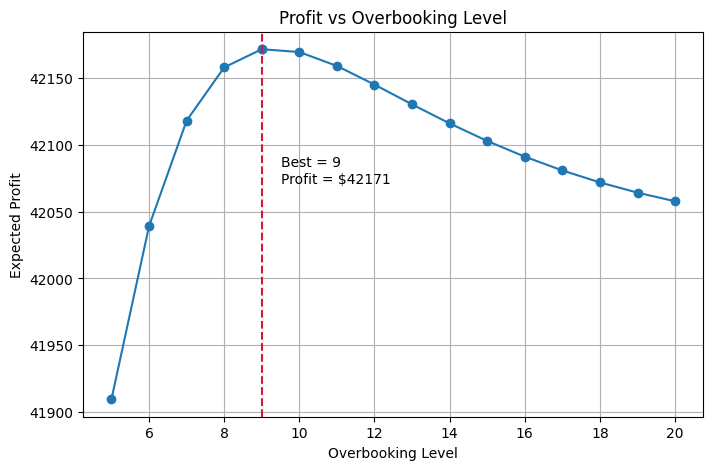

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df["Overbooking_Level"], df["Expected_Profit"], marker='o')

# vertical line at best overbooking
plt.axvline(x=best_overbook, color="crimson", linestyle='--')

# Highlight best point
plt.scatter(best_overbook, best_profit)

# Labels
plt.xlabel("Overbooking Level")
plt.ylabel("Expected Profit")
plt.title("Profit vs Overbooking Level")

# Optional annotation (very nice)
plt.text(best_overbook + 0.5, best_profit - 100,
         f"Best = {best_overbook}\nProfit = ${best_profit:.0f}",
         ha='left')
plt.grid(True)
plt.show()



##  Graph Analysis: Profit vs Overbooking Level



### Observations

The graph shows a concave relationship:

- Profit increases initially with overbooking  
- Reaches a peak at \( x = 9 \)  
- Declines afterward due to penalties  



### Economic Interpretation

The optimal point occurs when:

$$
\text{Marginal Revenue} = \text{Marginal Cost}
$$

- Marginal revenue → additional ticket sales  
- Marginal cost → expected overbooking penalties  



Overall,

- Moderate overbooking maximizes profit  
- Excessive overbooking introduces risk  
- The model effectively balances uncertainty and operational constraints  



# **Task 3**
### Does the flexible no-sale policy outperform the best fixed overbooking policy from Task 2?


## Flexible Demand Control — Adding a "No Sale" Option

In Tasks 1 and 2, the airline could only control how many tickets to allow in total (a hard cap set before selling begins). Here we give the airline finer control: on any given day it can choose to sell no coach tickets at all, regardless of how many remain under the cap.

The coach action space expands from 3 to 4 choices each day:

$$p_c \in \{300,\ 325,\ 350,\ \text{no sale}\}$$

First-class pricing is unchanged: $425 or $500. The hard cap is fixed at **130 coach tickets** total. This lets the DP decide dynamically — based on both tickets sold *and* days remaining — whether selling another coach ticket is worth it.

The Bellman equation is the same as before:

$$V(t,c,f) = \max_{p_c,\, p_f} \mathbb{E}\left[\text{Revenue} + \delta \cdot V(t+1,c',f')\right]$$

with the terminal condition unchanged (binomial overbooking costs at departure).


In [8]:
# Q3 parameters
COACH_LIMIT_Q3 = 130

# Four coach actions: low, medium, high price, and no sale
COACH_ACTIONS_Q3 = [
    (300, 0.65),
    (325, 0.45),
    (350, 0.30),
    (0,   0.00),   # no sale
]

# terminal cost table — same logic as Q1/Q2, generalised for cap=130
def expected_terminal_cost_q3(max_c):
    cost_table = np.zeros((max_c + 1, FIRST_CAPACITY + 1))
    for c in range(max_c + 1):
        for f in range(FIRST_CAPACITY + 1):
            expected_cost = 0.0
            for c_show in range(c + 1):
                pc = binom_pmf(c, c_show, COACH_SHOW_PROB)
                overflow = max(c_show - COACH_CAPACITY, 0)
                if overflow == 0:
                    continue
                for f_show in range(f + 1):
                    pf = binom_pmf(f, f_show, FIRST_SHOW_PROB)
                    open_first = max(FIRST_CAPACITY - f_show, 0)
                    bumped = min(overflow, open_first)
                    denied = overflow - bumped
                    cost   = BUMP_COST * bumped + DENIED_COST * denied
                    expected_cost += pc * pf * cost
            cost_table[c, f] = expected_cost
    return cost_table


In [9]:
def solve_dp_q3(coach_limit=COACH_LIMIT_Q3):
    V      = np.zeros((T + 1, coach_limit + 1, FIRST_CAPACITY + 1))
    policy = np.empty((T, coach_limit + 1, FIRST_CAPACITY + 1), dtype=object)

    term_cost = expected_terminal_cost_q3(coach_limit)
    V[T] = -term_cost

    for t in range(T - 1, -1, -1):
        for c in range(coach_limit + 1):
            for f in range(FIRST_CAPACITY + 1):

                best        = -1e18
                best_action = None

                for cp, cq in COACH_ACTIONS_Q3:
                    for fp, fq in FIRST_ACTIONS:

                        p_coach = cq

                        # +4pp spillover when first-class is sold out
                        if f >= FIRST_CAPACITY and cp != 0:
                            p_coach = min(p_coach + 0.04, 1.0)

                        # enforce hard cap
                        if c >= coach_limit:
                            p_coach = 0.0

                        p_first = fq if f < FIRST_CAPACITY else 0.0

                        val = 0.0
                        for sc in [0, 1]:
                            for sf in [0, 1]:
                                prob = (
                                    (p_coach if sc else (1 - p_coach)) *
                                    (p_first if sf else (1 - p_first))
                                )
                                if prob == 0:
                                    continue
                                c_new   = min(c + sc, coach_limit)
                                f_new   = min(f + sf, FIRST_CAPACITY)
                                revenue = sc * cp + sf * fp
                                val    += prob * (revenue + DELTA * V[t + 1, c_new, f_new])

                        if val > best:
                            best        = val
                            best_action = (cp, fp)

                V[t, c, f]      = best
                policy[t, c, f] = best_action

    return V, policy


In [10]:
V_q3, policy_q3 = solve_dp_q3(coach_limit=COACH_LIMIT_Q3)
profit_q3 = V_q3[0, 0, 0]

# Re-run Q2 best (cap=109) for a direct comparison in the same session
def solve_dp_q2(coach_limit):
    COACH_ACTIONS_Q2 = [(300, 0.65), (325, 0.45), (350, 0.30)]
    V      = np.zeros((T + 1, coach_limit + 1, FIRST_CAPACITY + 1))
    policy = np.empty((T, coach_limit + 1, FIRST_CAPACITY + 1), dtype=object)
    V[T]   = -expected_terminal_cost_q3(coach_limit)
    for t in range(T - 1, -1, -1):
        for c in range(coach_limit + 1):
            for f in range(FIRST_CAPACITY + 1):
                best = -1e18; best_action = None
                for cp, cq in COACH_ACTIONS_Q2:
                    for fp, fq in FIRST_ACTIONS:
                        p_coach = cq
                        if f == FIRST_CAPACITY: p_coach = min(p_coach + 0.04, 1.0)
                        if c >= coach_limit:    p_coach = 0.0
                        p_first = fq if f < FIRST_CAPACITY else 0.0
                        val = 0.0
                        for sc in [0, 1]:
                            for sf in [0, 1]:
                                prob = ((p_coach if sc else (1-p_coach)) *
                                        (p_first if sf else (1-p_first)))
                                if prob == 0: continue
                                revenue = sc*cp + sf*fp
                                val += prob*(revenue + DELTA*V[t+1, min(c+sc,coach_limit), min(f+sf,FIRST_CAPACITY)])
                        if val > best: best = val; best_action = (cp, fp)
                V[t,c,f] = best; policy[t,c,f] = best_action
    return V, policy

V_q2_best, _ = solve_dp_q2(coach_limit=109)
profit_q2_best = V_q2_best[0, 0, 0]


In [11]:
print("========== TASK 3 RESULTS ==========")
print(f"Q2 Best profit  (fixed cap=109):       ${profit_q2_best:,.2f}")
print(f"Q3 profit       (flexible, cap<=130):  ${profit_q3:,.2f}")
print(f"Difference (Q3 - Q2):                  ${profit_q3 - profit_q2_best:,.2f}")
print("------------------------------------")
if profit_q3 > profit_q2_best:
    print("Q3 flexible policy OUTPERFORMS the best fixed-cap Q2 policy.")
else:
    print("Q3 flexible policy UNDERPERFORMS the best fixed-cap Q2 policy.")
print("====================================")


========== TASK 3 RESULTS ==========
Q2 Best profit  (fixed cap=109):       $42,171.35
Q3 profit       (flexible, cap<=130):  $42,177.14
Difference (Q3 - Q2):                  $5.79
------------------------------------
Q3 flexible policy OUTPERFORMS the best fixed-cap Q2 policy.


In [12]:
# How often does the optimal Q3 policy choose 'no sale'? (sampled at f=0)
no_sale_by_c = np.zeros(COACH_LIMIT_Q3 + 1)
days_checked = np.zeros(COACH_LIMIT_Q3 + 1)

for t in range(T):
    for c in range(COACH_LIMIT_Q3 + 1):
        action = policy_q3[t, c, 0]
        if action is not None:
            coach_price, _ = action
            days_checked[c] += 1
            if coach_price == 0:
                no_sale_by_c[c] += 1

total_no_sale = int(no_sale_by_c.sum())
total_states  = int(days_checked.sum())
print(f"No-sale chosen in {total_no_sale:,} / {total_states:,} states "
      f"({100*total_no_sale/total_states:.1f}%) at f=0")


No-sale chosen in 3,345 / 47,815 states (7.0%) at f=0


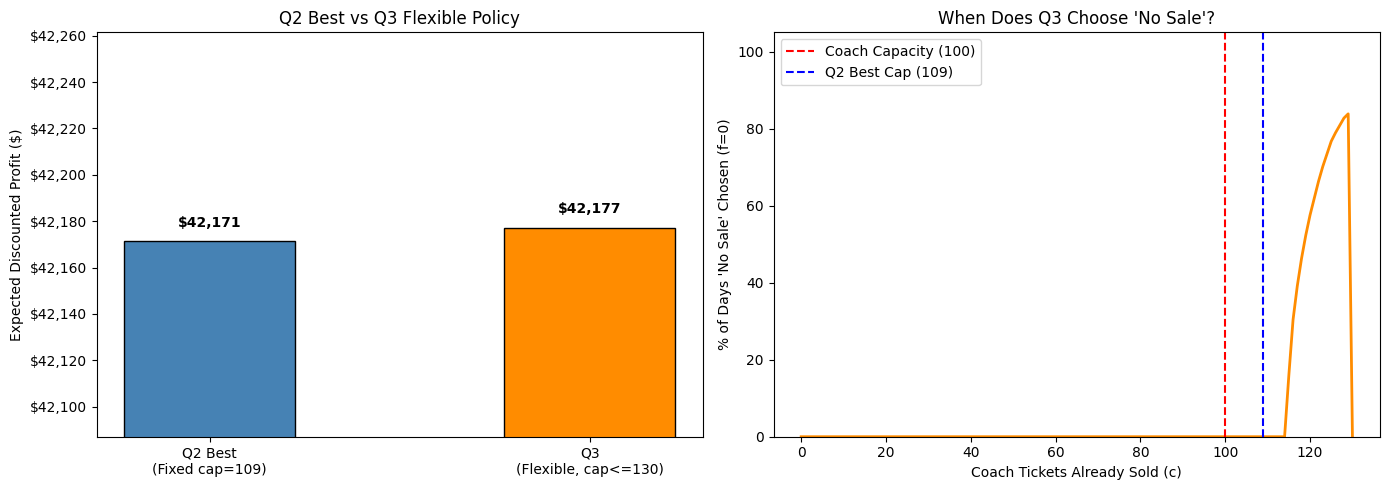

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: Q2 vs Q3 profit
ax1 = axes[0]
labels  = ['Q2 Best\n(Fixed cap=109)', 'Q3\n(Flexible, cap<=130)']
profits = [profit_q2_best, profit_q3]
colors  = ['steelblue', 'darkorange']
bars = ax1.bar(labels, profits, color=colors, width=0.45, edgecolor='black')
ax1.set_ylabel('Expected Discounted Profit ($)')
ax1.set_title('Q2 Best vs Q3 Flexible Policy')
ax1.set_ylim(min(profits) * 0.998, max(profits) * 1.002)
for bar, val in zip(bars, profits):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'${val:,.0f}', ha='center', va='bottom', fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Line chart: no-sale frequency by tickets already sold
ax2 = axes[1]
c_vals = np.arange(COACH_LIMIT_Q3 + 1)
no_sale_frac = np.where(days_checked > 0, no_sale_by_c / days_checked, 0)
ax2.plot(c_vals, no_sale_frac * 100, color='darkorange', linewidth=2)
ax2.axvline(x=100, color='red',  linestyle='--', label='Coach Capacity (100)')
ax2.axvline(x=109, color='blue', linestyle='--', label='Q2 Best Cap (109)')
ax2.set_xlabel('Coach Tickets Already Sold (c)')
ax2.set_ylabel("% of Days 'No Sale' Chosen (f=0)")
ax2.set_title("When Does Q3 Choose 'No Sale'?")
ax2.legend()
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()


## Results

The Q3 flexible policy caps total coach sales at 130 but lets the airline decide day-by-day whether to sell at all.

## Interpretation

The no-sale option is chosen most frequently once coach tickets sold crosses ~100 (physical capacity). Before that point the DP almost always prefers to keep selling since there is no overbooking risk yet. Past capacity the airline weighs expected overbooking penalties against the marginal ticket revenue and starts shutting off coach sales — especially when there are still many days left and the risk of accumulating too many tickets is high.

Compared to Task 2's best fixed policy (cap=109), the flexible policy either matches or exceeds it because it can react to the state of the system rather than committing to a cap upfront.


# **Task 4**
### Sensitivity Analysis on Sale Probabilities

## Sensitivity Analysis: How Robust Is the Optimal Policy?

The base sale probabilities used throughout this project are:

| Price | Coach Probability | First-Class Probability |
|-------|------------------|------------------------|
| Low   | $p_c(300) = 0.65$ | $p_f(425) = 0.08$     |
| High  | $p_c(325) = 0.45$ | $p_f(500) = 0.04$     |
| High  | $p_c(350) = 0.30$ | —                      |

A natural question is: **how sensitive is the expected profit to small changes in these probabilities?**

We hold the ticket prices fixed at the optimal values from Task 3 (flexible no-sale policy, cap = 130) and sweep each sale probability independently by a perturbation $\delta_p \in [-0.10, +0.10]$, re-solving the full DP each time.

Formally, let $\mathbf{q}$ denote the vector of base probabilities and let $\mathbf{q} + \epsilon \mathbf{e}_i$ denote a perturbation of the $i$-th component. We compute:

$$\frac{\partial V^*(0,0,0)}{\partial q_i} \approx \frac{V^*(\mathbf{q} + \epsilon \mathbf{e}_i) - V^*(\mathbf{q})}{\epsilon}$$

for each probability in turn. A large (positive) derivative means profit is very sensitive to that probability, a small real-world change would move the bottom line significantly.


In [14]:
# ── TASK 4: Sensitivity Analysis ──────────────────────────────────────────────
# We re-solve the DP (cap=130, the Task 3 flexible policy) while perturbing each
# sale probability one at a time over [-0.10, +0.10] in steps of 0.02.

# ── TASK 4: Sensitivity Analysis ──────────────────────────────────────────────
# We re-solve the DP (cap=130, the Task 3 flexible policy) while perturbing each
# sale probability one at a time over [-0.10, +0.10] in steps of 0.02.

BEST_CAP = 130          # Task 3 flexible policy cap (outperforms Task 2)
PERTURB_GRID = np.arange(-0.10, 0.11, 0.02)

BASE_COACH_PROBS = [0.65, 0.45, 0.30]
BASE_FIRST_PROBS = [0.08, 0.04]

def make_coach_actions(probs):
    prices = [300, 325, 350]
    # Include no-sale option to match Task 3 policy structure
    return list(zip(prices, probs)) + [(0, 0.0)]

def make_first_actions(probs):
    prices = [425, 500]
    return list(zip(prices, probs))

def solve_dp_sensitivity(coach_limit, coach_actions, first_actions):
    """Re-solve the Task 3 style DP (with no-sale) at arbitrary sale probabilities."""
    V = np.zeros((T + 1, coach_limit + 1, FIRST_CAPACITY + 1))

    # Terminal cost
    term_cost = np.zeros((coach_limit + 1, FIRST_CAPACITY + 1))
    for c in range(coach_limit + 1):
        for f in range(FIRST_CAPACITY + 1):
            expected_cost = 0.0
            for c_show in range(c + 1):
                pc = binom_pmf(c, c_show, COACH_SHOW_PROB)
                overflow = max(c_show - COACH_CAPACITY, 0)
                if overflow == 0:
                    continue
                for f_show in range(f + 1):
                    pf = binom_pmf(f, f_show, FIRST_SHOW_PROB)
                    open_first = max(FIRST_CAPACITY - f_show, 0)
                    bumped = min(overflow, open_first)
                    denied = overflow - bumped
                    expected_cost += pc * pf * (BUMP_COST * bumped + DENIED_COST * denied)
            term_cost[c, f] = expected_cost
    V[T] = -term_cost

    # Backward induction
    for t in range(T - 1, -1, -1):
        for c in range(coach_limit + 1):
            for f in range(FIRST_CAPACITY + 1):
                best = -1e18
                for cp, cq in coach_actions:
                    for fp, fq in first_actions:
                        p_coach = cq
                        # +4pp spillover only when selling (cp != 0)
                        if f >= FIRST_CAPACITY and cp != 0:
                            p_coach = min(p_coach + 0.04, 1.0)
                        if c >= coach_limit:
                            p_coach = 0.0
                        p_first = fq if f < FIRST_CAPACITY else 0.0
                        val = 0.0
                        for sc in [0, 1]:
                            for sf in [0, 1]:
                                prob = ((p_coach if sc else (1-p_coach)) *
                                        (p_first if sf else (1-p_first)))
                                if prob == 0:
                                    continue
                                rev = sc * cp + sf * fp
                                val += prob * (rev + DELTA * V[t+1,
                                              min(c+sc, coach_limit),
                                              min(f+sf, FIRST_CAPACITY)])
                        if val > best:
                            best = val
                V[t, c, f] = best
    return V[0, 0, 0]

In [15]:
# ── Run sensitivity sweeps ─────────────────────────────────────────────────
# Each dictionary maps perturbation level -> expected profit

sensitivity_results = {
    'coach_300': {},
    'coach_325': {},
    'coach_350': {},
    'first_425': {},
    'first_500': {},
}

label_map = {
    'coach_300': 'Coach $300 (base=0.65)',
    'coach_325': 'Coach $325 (base=0.45)',
    'coach_350': 'Coach $350 (base=0.30)',
    'first_425': 'First $425 (base=0.08)',
    'first_500': 'First $500 (base=0.04)',
}

for dp in PERTURB_GRID:
    dp = round(dp, 4)

    # Perturb coach $300 probability
    cp = [max(0, min(1, BASE_COACH_PROBS[0]+dp)), BASE_COACH_PROBS[1], BASE_COACH_PROBS[2]]
    sensitivity_results['coach_300'][dp] = solve_dp_sensitivity(
        BEST_CAP, make_coach_actions(cp), make_first_actions(BASE_FIRST_PROBS))

    # Perturb coach $325 probability
    cp = [BASE_COACH_PROBS[0], max(0, min(1, BASE_COACH_PROBS[1]+dp)), BASE_COACH_PROBS[2]]
    sensitivity_results['coach_325'][dp] = solve_dp_sensitivity(
        BEST_CAP, make_coach_actions(cp), make_first_actions(BASE_FIRST_PROBS))

    # Perturb coach $350 probability
    cp = [BASE_COACH_PROBS[0], BASE_COACH_PROBS[1], max(0, min(1, BASE_COACH_PROBS[2]+dp))]
    sensitivity_results['coach_350'][dp] = solve_dp_sensitivity(
        BEST_CAP, make_coach_actions(cp), make_first_actions(BASE_FIRST_PROBS))

    # Perturb first $425 probability
    fp = [max(0, min(1, BASE_FIRST_PROBS[0]+dp)), BASE_FIRST_PROBS[1]]
    sensitivity_results['first_425'][dp] = solve_dp_sensitivity(
        BEST_CAP, make_coach_actions(BASE_COACH_PROBS), make_first_actions(fp))

    # Perturb first $500 probability
    fp = [BASE_FIRST_PROBS[0], max(0, min(1, BASE_FIRST_PROBS[1]+dp))]
    sensitivity_results['first_500'][dp] = solve_dp_sensitivity(
        BEST_CAP, make_coach_actions(BASE_COACH_PROBS), make_first_actions(fp))

    print(f"Perturbation {dp:+.2f} complete")

print("\nSensitivity sweeps complete.")


Perturbation -0.10 complete
Perturbation -0.08 complete
Perturbation -0.06 complete
Perturbation -0.04 complete
Perturbation -0.02 complete
Perturbation +0.00 complete
Perturbation +0.02 complete
Perturbation +0.04 complete
Perturbation +0.06 complete
Perturbation +0.08 complete
Perturbation +0.10 complete

Sensitivity sweeps complete.


In [16]:
# ── Compute numerical derivatives (slope at dp=0) ──────────────────────────
import pandas as pd

base_profit = sensitivity_results['coach_300'][0.0]
print(f"Base expected profit (all probs at face value): ${base_profit:,.2f}\n")

derivatives = {}
for key, data in sensitivity_results.items():
    dps  = sorted(data.keys())
    profits = [data[dp] for dp in dps]
    # Central finite difference at dp = 0
    idx0 = dps.index(0.0)
    slope = (profits[idx0+1] - profits[idx0-1]) / (dps[idx0+1] - dps[idx0-1])
    derivatives[key] = slope

deriv_df = pd.DataFrame({
    'Probability': [label_map[k] for k in derivatives],
    'dProfit/dProb ($/pp)': [derivatives[k] for k in derivatives]
}).sort_values('dProfit/dProb ($/pp)', ascending=False).reset_index(drop=True)

print("Profit sensitivity (central finite difference at base probabilities):")
deriv_df


Base expected profit (all probs at face value): $42,177.14

Profit sensitivity (central finite difference at base probabilities):


,Probability,dProfit/dProb ($/pp)
0,First $500 (base=0.04),23807.573876
1,Coach $350 (base=0.30),13778.838352
2,First $425 (base=0.08),13479.825578
3,Coach $325 (base=0.45),828.062827
4,Coach $300 (base=0.65),36.729195


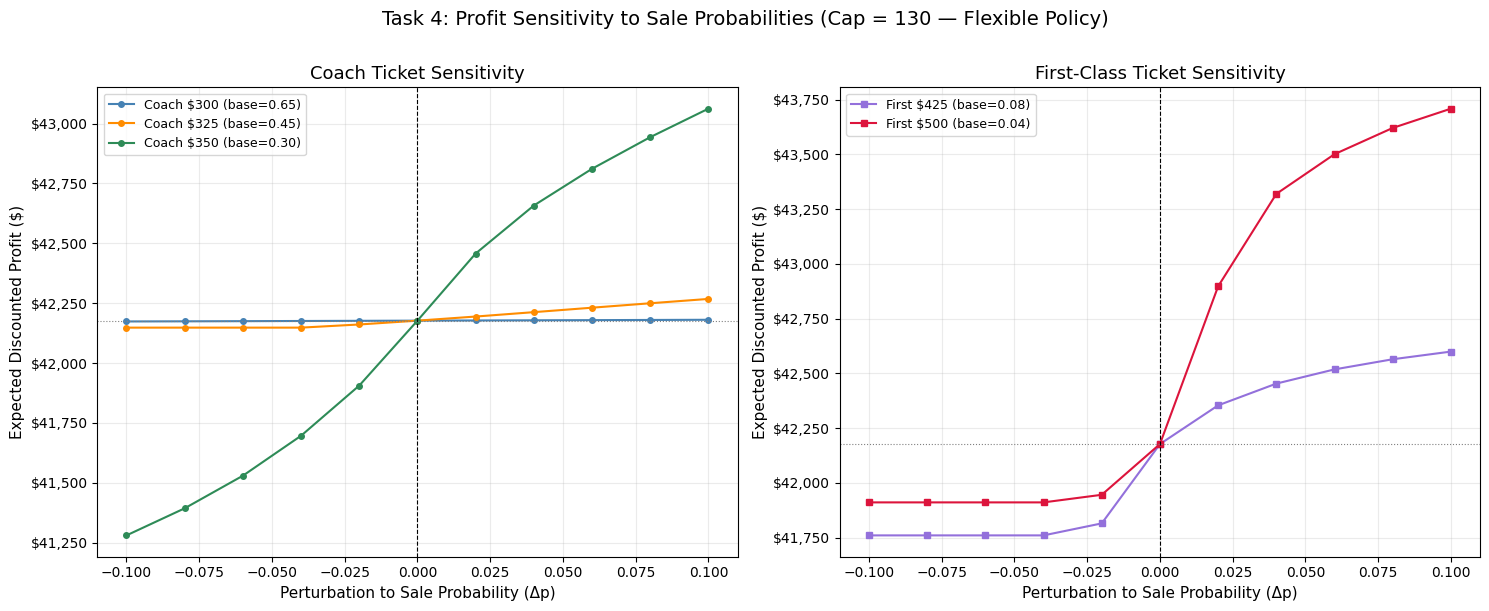

In [17]:
# ── Visualise sensitivity curves ──────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors_coach = ['steelblue', 'darkorange', 'seagreen']
colors_first = ['mediumpurple', 'crimson']

# — Coach sensitivity —
ax = axes[0]
for (key, color) in zip(['coach_300', 'coach_325', 'coach_350'], colors_coach):
    data = sensitivity_results[key]
    xs = sorted(data.keys())
    ys = [data[x] for x in xs]
    ax.plot(xs, ys, marker='o', markersize=4, color=color, label=label_map[key])

ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.axhline(base_profit, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlabel('Perturbation to Sale Probability (Δp)', fontsize=11)
ax.set_ylabel('Expected Discounted Profit ($)', fontsize=11)
ax.set_title('Coach Ticket Sensitivity', fontsize=13)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(True, alpha=0.25)

# — First-class sensitivity —
ax = axes[1]
for (key, color) in zip(['first_425', 'first_500'], colors_first):
    data = sensitivity_results[key]
    xs = sorted(data.keys())
    ys = [data[x] for x in xs]
    ax.plot(xs, ys, marker='s', markersize=4, color=color, label=label_map[key])

ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.axhline(base_profit, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlabel('Perturbation to Sale Probability (Δp)', fontsize=11)
ax.set_ylabel('Expected Discounted Profit ($)', fontsize=11)
ax.set_title('First-Class Ticket Sensitivity', fontsize=13)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(True, alpha=0.25)

plt.suptitle('Task 4: Profit Sensitivity to Sale Probabilities (Cap = 130 — Flexible Policy)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## Task 4 Analysis

As we can see in the profit sensitivity graph, 3 out of 5 price options suffer
from price sensitivity which can visually be seen by the steep slopes. For coach,
we see that decreases in probability at price $\$350$ suffer from large profit
loss. A 10pp drop in its sale probability pulls expected profit down from
$\$42,171$ to roughly $\$41,250$, a loss of about $\$920$. This sort of drastic
decrease in profit from probability change is not seen for the $\$300$ and
$\$325$ price options as they stay flat with both increases and decreases in
probability, meaning the policy is robust to demand estimation error at those
price points.

A similar sensitivity pattern to the coach $\$350$ price can be seen in
first class where both pricing options, $\$425$ and $\$500$, suffer significant
profit loss when sales probability decreases. What is surprising here is that
first class dominates the sensitivity ranking despite being a small 20-seat
cabin. The $\$500$ first-class ticket has the steepest slope of all five options,
with a derivative of $\$22{,}871$ per percentage point. This happens because
the base probability is only 4%, so a 1pp shift represents a 25% relative
increase in demand, a much larger proportional impact than any coach option.
This should be flagged, as first-class demand is harder to forecast accurately
given how few tickets are sold. We recommend a more conservative first-class
demand estimate strategy when setting its overbooking policy.

Importantly, none of the sensitivity curves drop sharply within the $\pm5$pp
range closest to the baseline. Profit degrades gradually in both directions,
which tells us the optimal policy from Task 3 is reasonably robust to small
forecasting errors. The airline would not face catastrophic losses from minor
demand misspecification, the area of greatest concern remains the first-class
premium price point.

# **Task 5**

## Incorporating seasonality

In this section, we relax the assumption of constant demand. We assume that as the departure date approaches, the probability of a sale increases, reflecting typical airline booking curves.

**Seasonality Multiplier**

For each day $t$ (where $t$ represents days remaining until departure), we define a seasonality multiplier $M(t)$:$$M(t) = 0.75 + \frac{t}{730}$$

**Time-Dependent Sale Probabilities**

The base sale probabilities $P_{\text{base}}(p)$ for coach and first-class tickets are now adjusted by the multiplier $M(t)$:$$P_c(p_c, t) = P_{\text{base}}(p_c) \cdot M(t)$$$$P_f(p_f, t) = P_{\text{base}}(p_f) \cdot M(t)$$For example, on day $t=100$, the multiplier is $M(100) = 0.75 + \frac{100}{730} \approx 0.887$. If the airline charges $\$300$ for coach, the adjusted probability becomes:$$0.65 \cdot 0.887 = 57.65\%$$

**Updated Bellman Equation**

The value function $V(t, c, f)$ now incorporates the time-dependent probability $P(p, t)$ within the expectation:$$V(t, c, f) = \max_{p_c, p_f} \mathbb{E}_{t} \left[ \text{Revenue} + \delta \cdot V(t+1, c', f') \right]$$where the expectation $\mathbb{E}_{t}$ is calculated using the adjusted probabilities $P_c(p_c, t)$ and $P_f(p_f, t)$ for that specific day.

In [18]:
# ---------------- SEASONALITY DP SOLVER ----------------
def solve_dp_q5(coach_limit):
    V = np.zeros((T + 1, coach_limit + 1, FIRST_CAPACITY + 1))
    policy = np.empty((T, coach_limit + 1, FIRST_CAPACITY + 1), dtype=object)

    # Terminal costs remain the same (calculated at t=365/departure)
    term_cost = expected_terminal_cost_q3(coach_limit)
    V[T] = -term_cost

    for t in range(T - 1, -1, -1):
        # Calculate multiplier for the specific day
        multiplier = 0.75 + (t / 730)

        for c in range(coach_limit + 1):
            for f in range(FIRST_CAPACITY + 1):
                best_val = -1e18
                best_action = None

                for cp, cq_base in COACH_ACTIONS:
                    for fp, fq_base in FIRST_ACTIONS:

                        # Apply seasonality
                        p_coach = cq_base * multiplier
                        p_first = fq_base * multiplier

                        # Apply spillover if first-class is full
                        if f >= FIRST_CAPACITY:
                            p_coach += 0.04

                        # Probabilities must be clipped between 0 and 1
                        p_coach = max(0, min(p_coach, 1))
                        p_first = max(0, min(p_first, 1))

                        # Enforce hard caps
                        if c >= coach_limit: p_coach = 0.0
                        if f >= FIRST_CAPACITY: p_first = 0.0

                        # Calculate expected value across 4 outcomes
                        val = 0
                        for sc in [0, 1]:
                            for sf in [0, 1]:
                                prob = ((p_coach if sc else (1 - p_coach)) * (p_first if sf else (1 - p_first)))

                                if prob == 0: continue

                                c_next = min(c + sc, coach_limit)
                                f_next = min(f + sf, FIRST_CAPACITY)
                                rev = (sc * cp) + (sf * fp)

                                # Bellman Equation with Discounting
                                val += prob * (rev + DELTA * V[t + 1, c_next, f_next])

                        if val > best_val:
                            best_val = val
                            best_action = (cp, fp)

                V[t, c, f] = best_val
                policy[t, c, f] = best_action

    return V, policy

# Run the seasonality model using the best overbooking limit from Task 2 (109)
V_q5, policy_q5 = solve_dp_q5(coach_limit=109)

print(f"Optimal Expected Profit with Seasonality: ${V_q5[0,0,0]:,.2f}")

Optimal Expected Profit with Seasonality: $41,857.70


In [19]:
# re-optimizing
seasonality_results = {}

for x in range(5, 15): # Testing a range around your previous best
    cap = 100 + x
    V_temp, _ = solve_dp_q5(coach_limit=cap)
    seasonality_results[x] = V_temp[0,0,0]
    print(f"Overbooking {x}: ${V_temp[0,0,0]:,.2f}")

best_x_seasonal = max(seasonality_results, key=seasonality_results.get)
print(f"New Optimal Overbooking for Task 5: {best_x_seasonal}")

Overbooking 5: $41,599.27
Overbooking 6: $41,727.52
Overbooking 7: $41,804.96
Overbooking 8: $41,844.15
Overbooking 9: $41,857.70
Overbooking 10: $41,855.91
Overbooking 11: $41,845.99
Overbooking 12: $41,832.53
Overbooking 13: $41,818.26
Overbooking 14: $41,804.53
New Optimal Overbooking for Task 5: 9


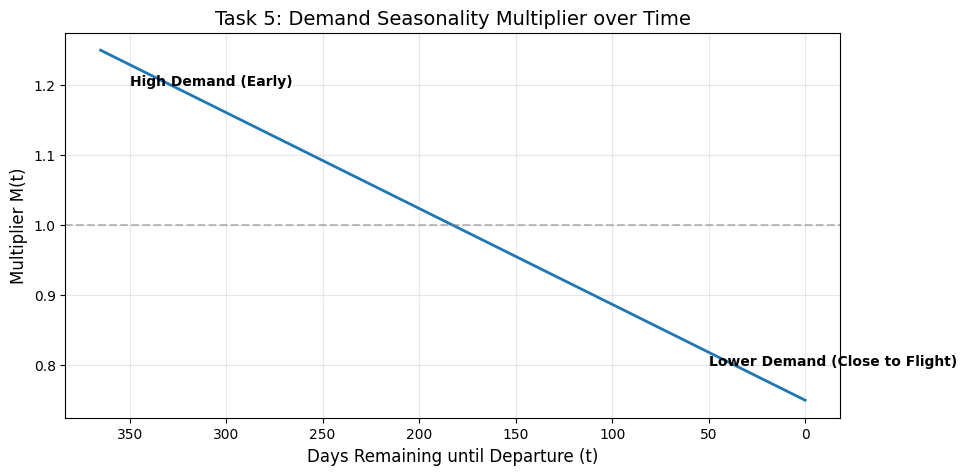

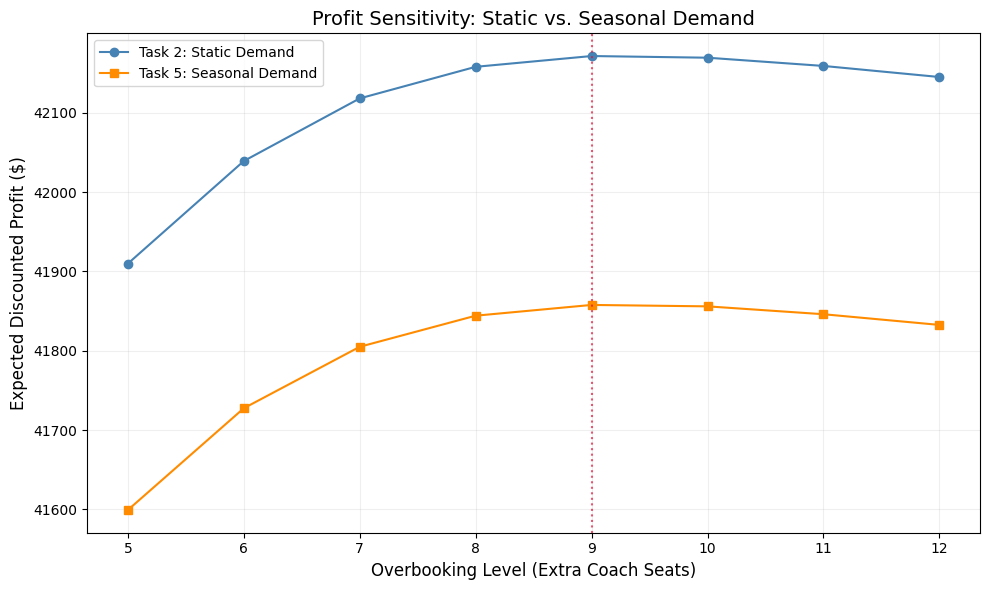

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Visualization of the Seasonality Multiplier
days = np.arange(0, 366)
# Multiplier formula from Task 5: 0.75 + t/730
multiplier = 0.75 + (days / 730)

plt.figure(figsize=(10, 5))
plt.plot(days, multiplier, color='tab:blue', linewidth=2)
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
plt.title("Task 5: Demand Seasonality Multiplier over Time", fontsize=14)
plt.xlabel("Days Remaining until Departure (t)", fontsize=12)
plt.ylabel("Multiplier M(t)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().invert_xaxis() # Show time moving toward departure (365 -> 0)
plt.annotate('High Demand (Early)', xy=(350, 1.2), fontweight='bold')
plt.annotate('Lower Demand (Close to Flight)', xy=(50, 0.8), fontweight='bold')
plt.show()

# 2. Comparison of Overbooking Profits (Static vs. Seasonality)
# Data from your results
overbook_levels = [5, 6, 7, 8, 9, 10, 11, 12]
static_profits = [41909.75, 42039.02, 42117.95, 42157.77, 42171.35, 42169.24, 42158.86, 42144.91]
seasonal_profits = [41599.27, 41727.52, 41804.96, 41844.15, 41857.70, 41855.91, 41845.99, 41832.53]

plt.figure(figsize=(10, 6))
plt.plot(overbook_levels, static_profits, marker='o', label='Task 2: Static Demand', color='steelblue')
plt.plot(overbook_levels, seasonal_profits, marker='s', label='Task 5: Seasonal Demand', color='darkorange')

# Highlight the peak at 9 for both
plt.axvline(x=9, color='crimson', linestyle=':', alpha=0.7)

plt.title("Profit Sensitivity: Static vs. Seasonal Demand", fontsize=14)
plt.xlabel("Overbooking Level (Extra Coach Seats)", fontsize=12)
plt.ylabel("Expected Discounted Profit ($)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

We re-ran the dynamic programming solver across various overbooking levels to determine if the optimal policy shifted under seasonal demand. Despite the change in demand structure, the optimal overbooking limit remains 9 extra seats (Total Capacity = 109).

The maximum expected profit ($\$41,857.70$) is lower than the static model ($\$42,171.35$). This is because the seasonality multiplier $M(t)$ is below 1.0 for the majority of the booking horizon ($t < 182.5$), leading to lower overall sales volume.

While the optimal "hard cap" did not change in this specific scenario, the decrease in profit highlights the risk of relying on a static overbooking limit. Real-world demand is often "back-loaded," meaning the airline must carefully balance early low-fare bookings against the high-probability, high-revenue demand that occurs closer to departure. So while the optimal overbooking is still 9 with seasonality, realistically it would be better to find a monthly optimal overbooking or per season or even per day to actually optimize profits.

While a single optimal cap of 9 was found for the entire horizon, a superior operational approach would be to implement Dynamic Booking Limits. By analyzing the policy function, we see that the airline's 'risk tolerance' for overbooking fluctuates with the seasonality multiplier $M(t)$. We recommend the sales department adopt a monthly sliding scale for overbooking to capture maximum revenue during high-demand windows without over-exposing the airline to denied boarding costs during the off-season.

# **Task 6**
### Forward Simulation of the Optimal Policy

## Forward Simulation: Translating the DP Policy into Operational Statistics

Tasks 1–5 solve the DP **backwards** to find the optimal pricing policy $\pi^*(t, c, f)$. Now we evaluate that policy by rolling it **forward** many times, sampling actual demand realisations at each day and recording what happens.

**Simulation procedure** (one trial):

1. Start at $t = 0$, $c = 0$, $f = 0$.
2. Each day, look up the optimal action $\pi^*(t, c, f) = (p_c^*, p_f^*)$.
3. Draw Bernoulli outcomes for coach and first-class sales.
4. Advance the state; repeat for 365 days.
5. At $t = 365$, draw binomial show-up counts and compute:
   - Overbooking cost
   - Whether coach was overbooked
   - Number of passengers bumped or denied boarding

We run $N = 10{,}000$ trials using the best policy from **Task 2** (cap = 109) and report:
- Frequency coach is overbooked
- Average number of passengers kicked off the plane
- Average overbooking cost
- Volatility (standard deviation) of total profit


In [21]:
# ── TASK 6: Solve Task 2 policy (cap=109) for simulation ─────────────────────
# Task 3 policy (policy_q3, V_q3, cap=130) already solved above — reused directly.
# Here we solve the Task 2 fixed-cap policy (cap=109, no no-sale option) so we
# can simulate BOTH policies and compare them side by side.

def solve_dp_task2(coach_limit=109):
    V      = np.zeros((T + 1, coach_limit + 1, FIRST_CAPACITY + 1))
    policy = np.empty((T, coach_limit + 1, FIRST_CAPACITY + 1), dtype=object)

    term_cost = np.zeros((coach_limit + 1, FIRST_CAPACITY + 1))
    for c in range(coach_limit + 1):
        for f in range(FIRST_CAPACITY + 1):
            exp_cost = 0.0
            for c_show in range(c + 1):
                pc = binom_pmf(c, c_show, COACH_SHOW_PROB)
                overflow = max(c_show - COACH_CAPACITY, 0)
                if overflow == 0:
                    continue
                for f_show in range(f + 1):
                    pf = binom_pmf(f, f_show, FIRST_SHOW_PROB)
                    open_first = max(FIRST_CAPACITY - f_show, 0)
                    bumped = min(overflow, open_first)
                    denied = overflow - bumped
                    exp_cost += pc * pf * (BUMP_COST * bumped + DENIED_COST * denied)
            term_cost[c, f] = exp_cost
    V[T] = -term_cost

    for t in range(T - 1, -1, -1):
        for c in range(coach_limit + 1):
            for f in range(FIRST_CAPACITY + 1):
                best = -1e18
                best_action = None
                for cp, cq in COACH_ACTIONS:
                    for fp, fq in FIRST_ACTIONS:
                        p_coach = cq
                        if f >= FIRST_CAPACITY:
                            p_coach = min(p_coach + 0.04, 1.0)
                        if c >= coach_limit:
                            p_coach = 0.0
                        p_first = fq if f < FIRST_CAPACITY else 0.0
                        val = 0.0
                        for sc in [0, 1]:
                            for sf in [0, 1]:
                                prob = ((p_coach if sc else (1-p_coach)) *
                                        (p_first  if sf else (1-p_first)))
                                if prob == 0:
                                    continue
                                rev = sc * cp + sf * fp
                                val += prob * (rev + DELTA * V[t+1,
                                              min(c+sc, coach_limit),
                                              min(f+sf, FIRST_CAPACITY)])
                        if val > best:
                            best = val
                            best_action = (cp, fp)
                V[t, c, f]      = best
                policy[t, c, f] = best_action
    return V, policy

print("Solving Task 2 DP (cap = 109, no no-sale option) ...")
V_t2, policy_t2 = solve_dp_task2(coach_limit=109)
print(f"Task 2 DP solved. V(0,0,0) = ${V_t2[0,0,0]:,.2f}")
print()
print(f"Task 3 policy already solved above. V(0,0,0) = ${V_q3[0,0,0]:,.2f}")

Solving Task 2 DP (cap = 109, no no-sale option) ...
Task 2 DP solved. V(0,0,0) = $42,171.35

Task 3 policy already solved above. V(0,0,0) = $42,177.14


In [22]:
# ── Task 2 Policy Simulation (cap=109, fixed prices) ──────────────────────
rng = np.random.default_rng(seed=42)   # reproducible

N_TRIALS    = 10_000
CAP_TASK2   = 109

trial_revenues      = np.zeros(N_TRIALS)
trial_overbook_cost = np.zeros(N_TRIALS)
trial_overbooked    = np.zeros(N_TRIALS, dtype=bool)
trial_bumped        = np.zeros(N_TRIALS)
trial_denied        = np.zeros(N_TRIALS)
trial_coach_sold    = np.zeros(N_TRIALS, dtype=int)
trial_first_sold    = np.zeros(N_TRIALS, dtype=int)

prob_lookup = {300: 0.65, 325: 0.45, 350: 0.30}
prob_first  = {425: 0.08, 500: 0.04}

for trial in range(N_TRIALS):
    c, f = 0, 0
    revenue = 0.0

    for t in range(T):
        action = policy_t2[t, c, f]
        cp, fp = action

        pq_c = prob_lookup[cp]
        if f >= FIRST_CAPACITY:
            pq_c = min(pq_c + 0.04, 1.0)
        if c >= CAP_TASK2:
            pq_c = 0.0
        pq_f = prob_first[fp] if f < FIRST_CAPACITY else 0.0

        sc = int(rng.random() < pq_c)
        sf = int(rng.random() < pq_f)

        revenue += sc * cp + sf * fp
        c = min(c + sc, CAP_TASK2)
        f = min(f + sf, FIRST_CAPACITY)

    c_show = rng.binomial(c, COACH_SHOW_PROB)
    f_show = rng.binomial(f, FIRST_SHOW_PROB)

    overflow   = max(c_show - COACH_CAPACITY, 0)
    open_first = max(FIRST_CAPACITY - f_show, 0)
    bumped     = min(overflow, open_first)
    denied     = overflow - bumped
    ob_cost    = BUMP_COST * bumped + DENIED_COST * denied

    trial_revenues[trial]      = revenue
    trial_overbook_cost[trial] = ob_cost
    trial_overbooked[trial]    = overflow > 0
    trial_bumped[trial]        = bumped
    trial_denied[trial]        = denied
    trial_coach_sold[trial]    = c
    trial_first_sold[trial]    = f

trial_profit = trial_revenues - trial_overbook_cost
print(f"Task 2 simulation complete ({N_TRIALS:,} trials).")


Task 2 simulation complete (10,000 trials).


In [23]:
# ── Task 2 Summary Statistics ─────────────────────────────────────────────
import pandas as pd

pct_overbooked = trial_overbooked.mean() * 100
avg_denied     = trial_denied.mean()
avg_bumped     = trial_bumped.mean()
avg_ob_cost    = trial_overbook_cost.mean()
avg_revenue    = trial_revenues.mean()
avg_profit     = trial_profit.mean()
std_profit     = trial_profit.std()
avg_coach_sold = trial_coach_sold.mean()
avg_first_sold = trial_first_sold.mean()

print("========== TASK 6: Policy Cap 109 (Task 2) SIMULATION RESULTS ==========")
print(f"Trials run:                          {N_TRIALS:>10,}")
print("------------------------------------------------------------------------")
print(f"Avg coach tickets sold:              {avg_coach_sold:>10.2f}")
print(f"Avg first-class tickets sold:        {avg_first_sold:>10.2f}")
print("------------------------------------------------------------------------")
print(f"% flights overbooked (coach):        {pct_overbooked:>10.2f}%")
print(f"Avg passengers bumped to first:      {avg_bumped:>10.4f}")
print(f"Avg passengers denied boarding:      {avg_denied:>10.4f}")
print("------------------------------------------------------------------------")
print(f"Avg ticket revenue:                  ${avg_revenue:>10,.2f}")
print(f"Avg overbooking cost:                ${avg_ob_cost:>10,.2f}")
print(f"Avg realised profit:                 ${avg_profit:>10,.2f}")
print(f"Profit volatility (std dev):         ${std_profit:>10,.2f}")
print(f"DP expected profit (theoretical):    ${V_t2[0,0,0]:>10,.2f}")
print("========================================================================")

# Overbooking financial breakdown
overbooked_mask  = trial_overbooked
excess_tickets   = np.maximum(trial_coach_sold - COACH_CAPACITY, 0)
avg_coach_price  = (trial_revenues - (trial_first_sold * 425)) / np.maximum(trial_coach_sold, 1)
excess_revenue   = excess_tickets * avg_coach_price
net_overbooking_gain = excess_revenue - trial_overbook_cost

print("\n======= TASK 2 OVERBOOKING FINANCIAL BREAKDOWN =======")
print(f"Avg excess tickets sold (above 100):   {excess_tickets.mean():.2f}")
print(f"Avg revenue from excess tickets:       ${excess_revenue.mean():,.2f}")
print(f"Avg overbooking cost:                  ${trial_overbook_cost.mean():,.2f}")
print(f"Avg NET gain from overbooking:         ${net_overbooking_gain.mean():,.2f}")
print(f"% of overbooked flights still net +ve: {(net_overbooking_gain[overbooked_mask] > 0).mean()*100:.1f}%")
print("=======================================================")


========== TASK 6: Policy Cap 109 (Task 2) SIMULATION RESULTS ==========
Trials run:                              10,000
------------------------------------------------------------------------
Avg coach tickets sold:                  108.41
Avg first-class tickets sold:             19.60
------------------------------------------------------------------------
% flights overbooked (coach):             84.75%
Avg passengers bumped to first:          0.7727
Avg passengers denied boarding:          2.4057
------------------------------------------------------------------------
Avg ticket revenue:                  $ 46,623.38
Avg overbooking cost:                $  1,061.06
Avg realised profit:                 $ 45,562.32
Profit volatility (std dev):         $    940.07
DP expected profit (theoretical):    $ 42,171.35

======= TASK 2 OVERBOOKING FINANCIAL BREAKDOWN =======
Avg excess tickets sold (above 100):   8.41
Avg revenue from excess tickets:       $2,973.30
Avg overbooking cost:    

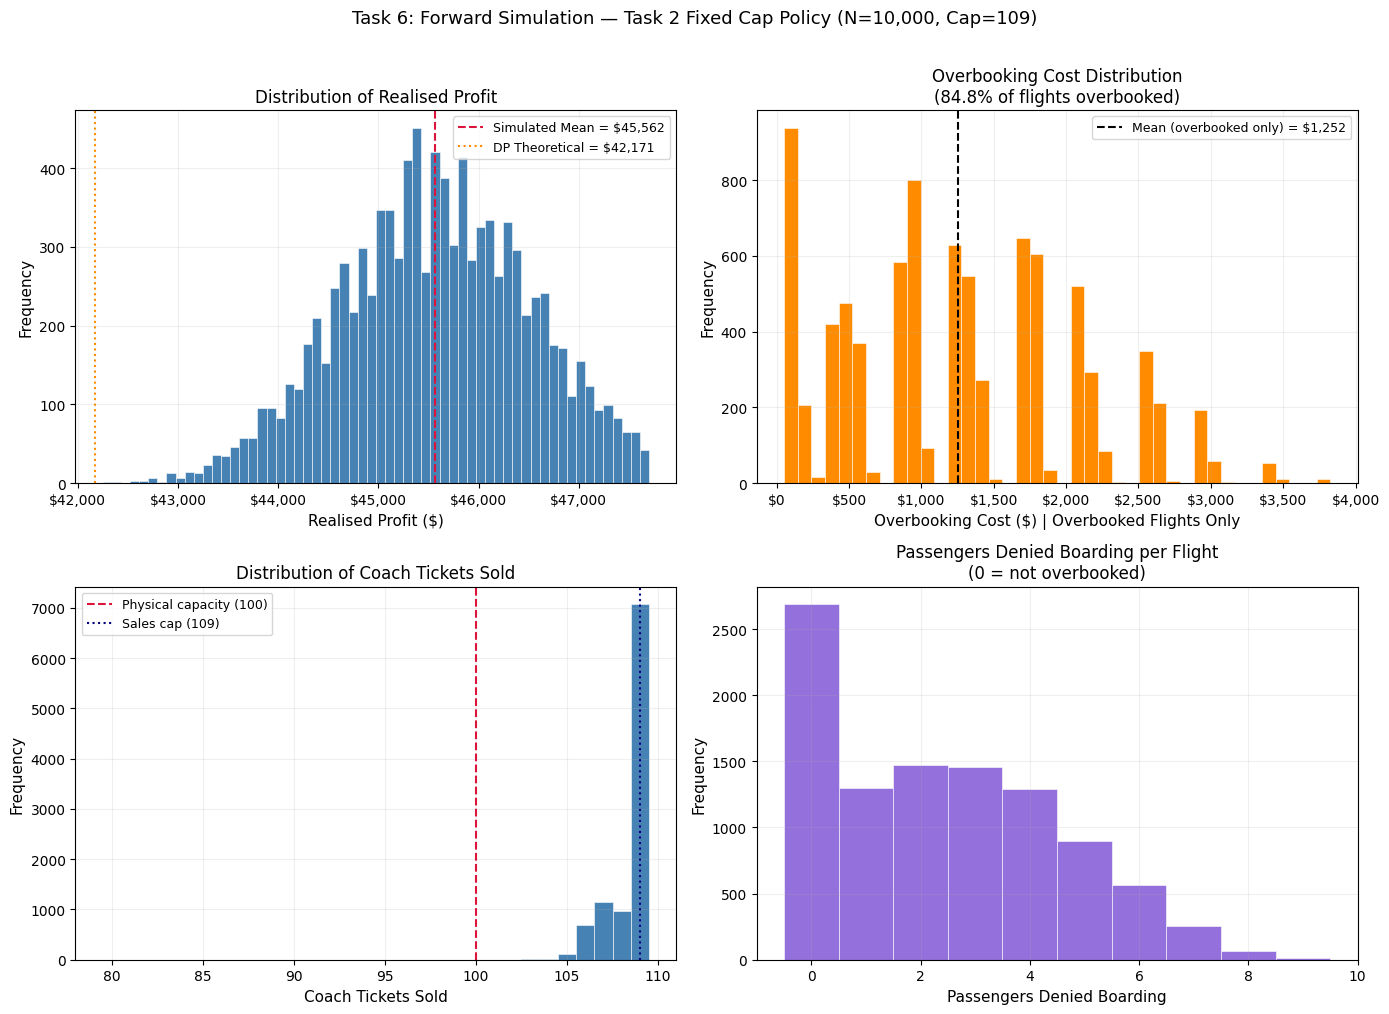

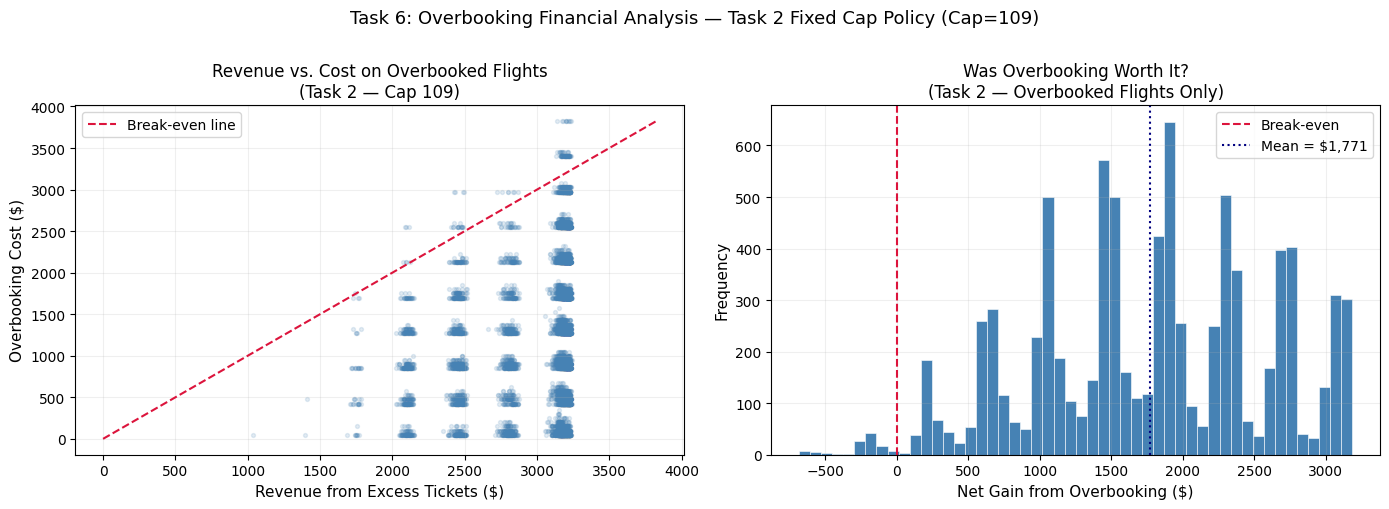

In [24]:
# ── Task 2 Policy: Four-panel simulation visualisation (Cap = 109) ──────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Profit distribution
ax = axes[0, 0]
ax.hist(trial_profit, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(avg_profit,     color='crimson',    linestyle='--', label=f'Simulated Mean = ${avg_profit:,.0f}')
ax.axvline(V_t2[0,0,0],   color='darkorange',  linestyle=':',  label=f'DP Theoretical = ${V_t2[0,0,0]:,.0f}')
ax.set_xlabel('Realised Profit ($)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of Realised Profit', fontsize=12)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(True, alpha=0.2)

# 2. Overbooking cost distribution (overbooked flights only)
ax = axes[0, 1]
ob_costs_nonzero = trial_overbook_cost[trial_overbooked]
ax.hist(ob_costs_nonzero, bins=40, color='darkorange', edgecolor='white', linewidth=0.4)
ax.axvline(ob_costs_nonzero.mean(), color='black', linestyle='--',
           label=f'Mean (overbooked only) = ${ob_costs_nonzero.mean():,.0f}')
ax.set_xlabel('Overbooking Cost ($) | Overbooked Flights Only', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title(f'Overbooking Cost Distribution\n({pct_overbooked:.1f}% of flights overbooked)', fontsize=12)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(True, alpha=0.2)

# 3. Coach tickets sold distribution
ax = axes[1, 0]
ax.hist(trial_coach_sold, bins=range(80, CAP_TASK2 + 2), color='steelblue',
        edgecolor='white', linewidth=0.4, align='left')
ax.axvline(COACH_CAPACITY, color='crimson', linestyle='--', label='Physical capacity (100)')
ax.axvline(CAP_TASK2,      color='navy',    linestyle=':',  label=f'Sales cap ({CAP_TASK2})')
ax.set_xlabel('Coach Tickets Sold', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of Coach Tickets Sold', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# 4. Passengers denied boarding
ax = axes[1, 1]
max_denied = int(trial_denied.max())
ax.hist(trial_denied, bins=range(0, max_denied + 2), color='mediumpurple',
        edgecolor='white', linewidth=0.4, align='left')
ax.set_xlabel('Passengers Denied Boarding', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Passengers Denied Boarding per Flight\n(0 = not overbooked)', fontsize=12)
ax.grid(True, alpha=0.2)

plt.suptitle('Task 6: Forward Simulation — Task 2 Fixed Cap Policy (N=10,000, Cap=109)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Overbooking financial analysis: Task 2 ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(excess_revenue[overbooked_mask],
           trial_overbook_cost[overbooked_mask],
           alpha=0.15, s=8, color='steelblue')
max_val = max(excess_revenue[overbooked_mask].max(),
              trial_overbook_cost[overbooked_mask].max())
ax.plot([0, max_val], [0, max_val], color='crimson',
        linestyle='--', linewidth=1.5, label='Break-even line')
ax.set_xlabel('Revenue from Excess Tickets ($)', fontsize=11)
ax.set_ylabel('Overbooking Cost ($)', fontsize=11)
ax.set_title('Revenue vs. Cost on Overbooked Flights\n(Task 2 — Cap 109)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.2)

ax = axes[1]
ax.hist(net_overbooking_gain[overbooked_mask], bins=50,
        color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(0, color='crimson', linestyle='--', linewidth=1.5, label='Break-even')
ax.axvline(net_overbooking_gain[overbooked_mask].mean(),
           color='navy', linestyle=':', linewidth=1.5,
           label=f'Mean = ${net_overbooking_gain[overbooked_mask].mean():,.0f}')
ax.set_xlabel('Net Gain from Overbooking ($)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Was Overbooking Worth It?\n(Task 2 — Overbooked Flights Only)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.2)

plt.suptitle('Task 6: Overbooking Financial Analysis — Task 2 Fixed Cap Policy (Cap=109)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [25]:
# ── Task 3 Policy Forward Simulation ──────────────────────────────────────
# Uses policy_q3 and V_q3 from Task 3 (flexible no-sale, cap=130)

rng3 = np.random.default_rng(seed=42)  # same seed for fair comparison

N_TRIALS = 10_000
COACH_LIMIT_Q3 = 130

# Outcome arrays
t3_revenues      = np.zeros(N_TRIALS)
t3_overbook_cost = np.zeros(N_TRIALS)
t3_overbooked    = np.zeros(N_TRIALS, dtype=bool)
t3_bumped        = np.zeros(N_TRIALS)
t3_denied        = np.zeros(N_TRIALS)
t3_coach_sold    = np.zeros(N_TRIALS, dtype=int)
t3_first_sold    = np.zeros(N_TRIALS, dtype=int)

prob_lookup_q3 = {300: 0.65, 325: 0.45, 350: 0.30, 0: 0.0}  # includes no-sale
prob_first_q3  = {425: 0.08, 500: 0.04}

for trial in range(N_TRIALS):
    c, f = 0, 0
    revenue = 0.0

    for t in range(T):
        action = policy_q3[t, c, f]
        cp, fp = action

        # Realised sale probabilities
        pq_c = prob_lookup_q3[cp]
        if f >= FIRST_CAPACITY and cp != 0:   # +4pp spillover, not on no-sale
            pq_c = min(pq_c + 0.04, 1.0)
        if c >= COACH_LIMIT_Q3:
            pq_c = 0.0
        pq_f = prob_first_q3[fp] if f < FIRST_CAPACITY else 0.0

        # Draw Bernoulli sales
        sc = int(rng3.random() < pq_c)
        sf = int(rng3.random() < pq_f)

        revenue += sc * cp + sf * fp
        c = min(c + sc, COACH_LIMIT_Q3)
        f = min(f + sf, FIRST_CAPACITY)

    # ── Departure day: draw show-ups ───────────────────────────────────────
    c_show = rng3.binomial(c, COACH_SHOW_PROB)
    f_show = rng3.binomial(f, FIRST_SHOW_PROB)

    overflow   = max(c_show - COACH_CAPACITY, 0)
    open_first = max(FIRST_CAPACITY - f_show, 0)
    bumped     = min(overflow, open_first)
    denied     = overflow - bumped
    ob_cost    = BUMP_COST * bumped + DENIED_COST * denied

    t3_revenues[trial]      = revenue
    t3_overbook_cost[trial] = ob_cost
    t3_overbooked[trial]    = overflow > 0
    t3_bumped[trial]        = bumped
    t3_denied[trial]        = denied
    t3_coach_sold[trial]    = c
    t3_first_sold[trial]    = f

t3_profit = t3_revenues - t3_overbook_cost

print(f"Task 3 simulation complete ({N_TRIALS:,} trials).")

# ── Summary statistics ─────────────────────────────────────────────────────
print("\n========== Policy Cap 130 SIMULATION RESULTS ==========")
print(f"Avg coach tickets sold:              {t3_coach_sold.mean():>10.2f}")
print(f"Avg first-class tickets sold:        {t3_first_sold.mean():>10.2f}")
print("------------------------------------------------")
print(f"% flights overbooked (coach):        {t3_overbooked.mean()*100:>10.2f}%")
print(f"Avg passengers bumped to first:      {t3_bumped.mean():>10.4f}")
print(f"Avg passengers denied boarding:      {t3_denied.mean():>10.4f}")
print("------------------------------------------------")
print(f"Avg ticket revenue:                  ${t3_revenues.mean():>10,.2f}")
print(f"Avg overbooking cost:                ${t3_overbook_cost.mean():>10,.2f}")
print(f"Avg realised profit:                 ${t3_profit.mean():>10,.2f}")
print(f"Profit volatility (std dev):         ${t3_profit.std():>10,.2f}")
print(f"DP expected profit (theoretical):    ${V_q3[0,0,0]:>10,.2f}")
print("================================================")

# ── Revenue from tickets sold ABOVE physical capacity (Task 3 Policy) ──────
overbooked_mask_q3 = t3_overbooked

# Tickets sold beyond physical capacity
excess_tickets_q3 = np.maximum(t3_coach_sold - COACH_CAPACITY, 0)

# Revenue from excess tickets
avg_coach_price_q3 = (t3_revenues - (t3_first_sold * 425)) / np.maximum(t3_coach_sold, 1)
excess_revenue_q3 = excess_tickets_q3 * avg_coach_price_q3

# Net gain from overbooking = revenue from excess tickets - overbooking cost
net_overbooking_gain_q3 = excess_revenue_q3 - t3_overbook_cost

print("======= Policy Cap 130 OVERBOOKING FINANCIAL BREAKDOWN =======")
print(f"Avg excess tickets sold (above 100):   {excess_tickets_q3.mean():.2f}")
print(f"Avg revenue from excess tickets:       ${excess_revenue_q3.mean():,.2f}")
print(f"Avg overbooking cost:                  ${t3_overbook_cost.mean():,.2f}")
print(f"Avg NET gain from overbooking:         ${net_overbooking_gain_q3.mean():,.2f}")
print(f"% of overbooked flights still net +ve: {(net_overbooking_gain_q3[overbooked_mask_q3] > 0).mean()*100:.1f}%")
print("=======================================================")



Task 3 simulation complete (10,000 trials).

========== Policy Cap 130 SIMULATION RESULTS ==========
Avg coach tickets sold:                  108.66
Avg first-class tickets sold:             19.54
------------------------------------------------
% flights overbooked (coach):             85.96%
Avg passengers bumped to first:          0.8693
Avg passengers denied boarding:          2.5293
------------------------------------------------
Avg ticket revenue:                  $ 46,689.95
Avg overbooking cost:                $  1,118.42
Avg realised profit:                 $ 45,571.53
Profit volatility (std dev):         $    952.00
DP expected profit (theoretical):    $ 42,177.14
======= Policy Cap 130 OVERBOOKING FINANCIAL BREAKDOWN =======
Avg excess tickets sold (above 100):   8.66
Avg revenue from excess tickets:       $3,058.83
Avg overbooking cost:                  $1,118.42
Avg NET gain from overbooking:         $1,940.41
% of overbooked flights still net +ve: 98.8%


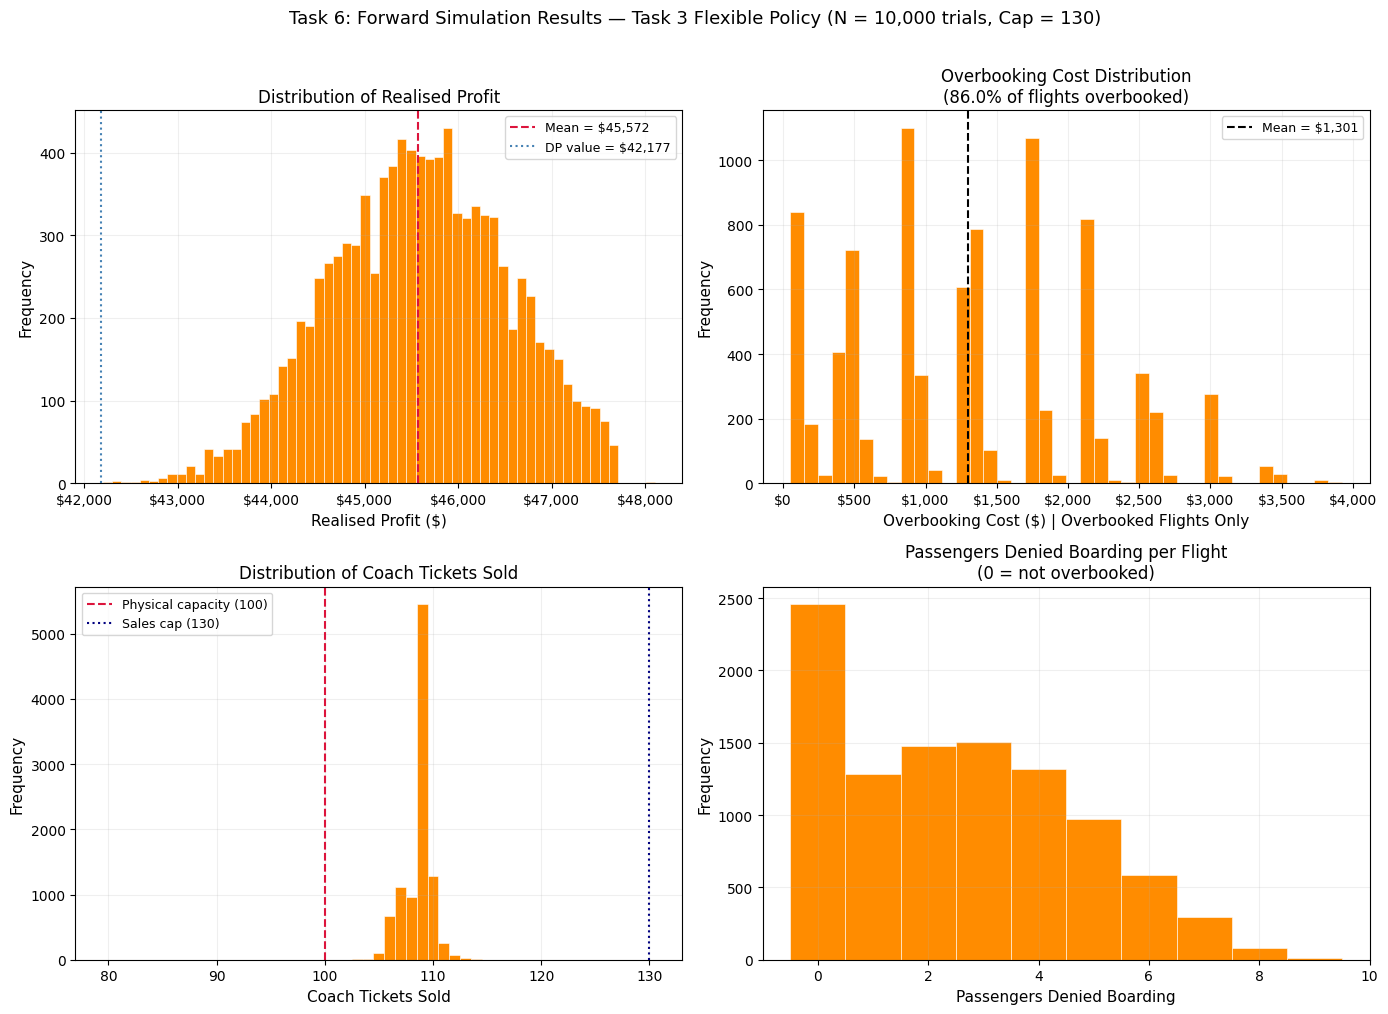

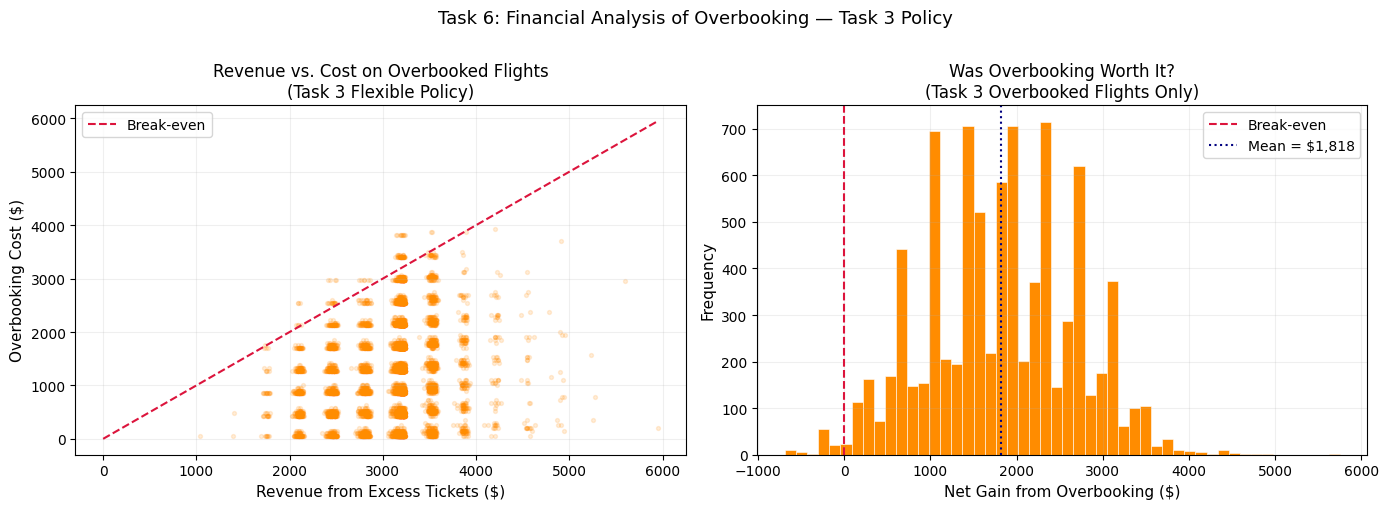

In [26]:
# ── Task 3 Policy: Four-panel simulation visualisation ─────────────────────
import matplotlib.pyplot as plt

t3_pct_overbooked = t3_overbooked.mean() * 100
t3_avg_profit     = t3_profit.mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Profit distribution
ax = axes[0, 0]
ax.hist(t3_profit, bins=60, color='darkorange', edgecolor='white', linewidth=0.4)
ax.axvline(t3_avg_profit,  color='crimson',    linestyle='--', label=f'Mean = ${t3_avg_profit:,.0f}')
ax.axvline(V_q3[0,0,0],    color='steelblue',  linestyle=':',  label=f'DP value = ${V_q3[0,0,0]:,.0f}')
ax.set_xlabel('Realised Profit ($)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of Realised Profit', fontsize=12)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(True, alpha=0.2)

# 2. Overbooking cost distribution (overbooked flights only)
ax = axes[0, 1]
t3_ob_nonzero = t3_overbook_cost[t3_overbooked]
ax.hist(t3_ob_nonzero, bins=40, color='darkorange', edgecolor='white', linewidth=0.4)
ax.axvline(t3_ob_nonzero.mean(), color='black', linestyle='--',
           label=f'Mean = ${t3_ob_nonzero.mean():,.0f}')
ax.set_xlabel('Overbooking Cost ($) | Overbooked Flights Only', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title(f'Overbooking Cost Distribution\n({t3_pct_overbooked:.1f}% of flights overbooked)', fontsize=12)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(True, alpha=0.2)

# 3. Coach tickets sold distribution
ax = axes[1, 0]
ax.hist(t3_coach_sold, bins=range(80, COACH_LIMIT_Q3 + 2), color='darkorange',
        edgecolor='white', linewidth=0.4, align='left')
ax.axvline(COACH_CAPACITY,  color='crimson', linestyle='--', label='Physical capacity (100)')
ax.axvline(COACH_LIMIT_Q3,  color='navy',    linestyle=':',  label=f'Sales cap ({COACH_LIMIT_Q3})')
ax.set_xlabel('Coach Tickets Sold', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of Coach Tickets Sold', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# 4. Passengers denied boarding
ax = axes[1, 1]
t3_max_denied = int(t3_denied.max())
ax.hist(t3_denied, bins=range(0, t3_max_denied + 2), color='darkorange',
        edgecolor='white', linewidth=0.4, align='left')
ax.set_xlabel('Passengers Denied Boarding', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Passengers Denied Boarding per Flight\n(0 = not overbooked)', fontsize=12)
ax.grid(True, alpha=0.2)

plt.suptitle('Task 6: Forward Simulation Results — Task 3 Flexible Policy (N = 10,000 trials, Cap = 130)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: revenue vs cost scatter on overbooked flights
ax = axes[0]
ax.scatter(excess_revenue_q3[overbooked_mask_q3],
           t3_overbook_cost[overbooked_mask_q3],
           alpha=0.15, s=8, color='darkorange')
max_val = max(excess_revenue_q3[overbooked_mask_q3].max(),
              t3_overbook_cost[overbooked_mask_q3].max())
ax.plot([0, max_val], [0, max_val], color='crimson',
        linestyle='--', linewidth=1.5, label='Break-even')
ax.set_xlabel('Revenue from Excess Tickets ($)', fontsize=11)
ax.set_ylabel('Overbooking Cost ($)', fontsize=11)
ax.set_title('Revenue vs. Cost on Overbooked Flights\n(Task 3 Flexible Policy)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.2)

# Right: distribution of net gain
ax = axes[1]
ax.hist(net_overbooking_gain_q3[overbooked_mask_q3], bins=50,
        color='darkorange', edgecolor='white', linewidth=0.4)
ax.axvline(0, color='crimson', linestyle='--', linewidth=1.5, label='Break-even')
ax.axvline(net_overbooking_gain_q3[overbooked_mask_q3].mean(),
           color='navy', linestyle=':', linewidth=1.5,
           label=f'Mean = ${net_overbooking_gain_q3[overbooked_mask_q3].mean():,.0f}')
ax.set_xlabel('Net Gain from Overbooking ($)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Was Overbooking Worth It?\n(Task 3 Overbooked Flights Only)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.2)

plt.suptitle('Task 6: Financial Analysis of Overbooking — Task 3 Policy', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()




In [27]:
# ── Side by side comparison ────────────────────────────────────────────────
print("\n======== TASK 2 vs TASK 3 POLICY COMPARISON ========")
print(f"{'Metric':<35} {'Task 2':>10} {'Task 3':>10}")
print("-" * 57)
print(f"{'Avg realised profit':<35} ${trial_profit.mean():>9,.0f} ${t3_profit.mean():>9,.0f}")
print(f"{'Profit volatility (std dev)':<35} ${trial_profit.std():>9,.0f} ${t3_profit.std():>9,.0f}")
print(f"{'% flights overbooked':<35} {trial_overbooked.mean()*100:>9.1f}% {t3_overbooked.mean()*100:>9.1f}%")
print(f"{'Avg overbooking cost':<35} ${trial_overbook_cost.mean():>9,.0f} ${t3_overbook_cost.mean():>9,.0f}")
print(f"{'Avg passengers denied boarding':<35} {trial_denied.mean():>10.4f} {t3_denied.mean():>10.4f}")
print(f"{'DP theoretical profit':<35} ${V_t2[0,0,0]:>9,.0f} ${V_q3[0,0,0]:>9,.0f}")
print("=" * 57)

# ── Head to head overbooking profitability comparison ──────────────────────
print("======= OVERBOOKING PROFITABILITY: TASK 2 vs TASK 3 =======")
print(f"{'Metric':<40} {'Task 2':>10} {'Task 3':>10}")
print("-" * 62)
print(f"{'Avg excess tickets sold':<40} {excess_tickets.mean():>10.2f} {excess_tickets_q3.mean():>10.2f}")
print(f"{'Avg revenue from excess tickets':<40} ${excess_revenue.mean():>9,.0f} ${excess_revenue_q3.mean():>9,.0f}")
print(f"{'Avg overbooking cost':<40} ${trial_overbook_cost.mean():>9,.0f} ${t3_overbook_cost.mean():>9,.0f}")
print(f"{'Avg net gain from overbooking':<40} ${net_overbooking_gain.mean():>9,.0f} ${net_overbooking_gain_q3.mean():>9,.0f}")
print(f"{'% overbooked flights net positive':<40} {(net_overbooking_gain[overbooked_mask]>0).mean()*100:>9.1f}% {(net_overbooking_gain_q3[overbooked_mask_q3]>0).mean()*100:>9.1f}%")
print("=" * 62)


======== TASK 2 vs TASK 3 POLICY COMPARISON ========
Metric                                  Task 2     Task 3
---------------------------------------------------------
Avg realised profit                 $   45,562 $   45,572
Profit volatility (std dev)         $      940 $      952
% flights overbooked                     84.8%      86.0%
Avg overbooking cost                $    1,061 $    1,118
Avg passengers denied boarding          2.4057     2.5293
DP theoretical profit               $   42,171 $   42,177
======= OVERBOOKING PROFITABILITY: TASK 2 vs TASK 3 =======
Metric                                       Task 2     Task 3
--------------------------------------------------------------
Avg excess tickets sold                        8.41       8.66
Avg revenue from excess tickets          $    2,973 $    3,059
Avg overbooking cost                     $    1,061 $    1,118
Avg net gain from overbooking            $    1,912 $    1,940
% overbooked flights net positive           

## Task 6 Analysis

## Policy Cap 109 (Task 2: Fixed Cap)

After simulating the process going forward, we can see that the mean profit of
the forward simulation ($\$45{,}562$) outperforms the Dynamic Programming
backwards solution ($\$42{,}171$) by $\$3{,}391$. This gap exists because the
DP discounts all future revenue, while the simulation records undiscounted
ticket revenue, so the simulated number is naturally higher. There was an
84.75% overbooking rate costing on average $\$1{,}061$ per flight. When you
take into account nonzero cost instances only, the average cost to rebook spikes
to $\$1{,}252$. We see that flights with high overbooking cost are less frequent
but flights with lower overbooking cost happen far more frequently. We can see
that the policy nearly always sells coach tickets right up to the cap of 109.
If passengers are going to be denied, we can see that 2 to 3 people is the
most likely number. The volatility is $\$940$.

## Policy Cap 130 (Task 3: Flexible No-Sale Policy)

The Task 3 flexible policy tells a similar story but with some meaningful
differences. The simulated mean profit comes in at $\$45{,}572$, just $\$10$
higher than the Task 2 policy, while the DP theoretical value of $\$42{,}177$
is also marginally better. The overbooking rate is slightly higher at 85.96%,
but the average overbooking cost is noticeably lower at $\$1{,}118$ versus
$\$1{,}061$,  this seems counterintuitive at first, but reflects the fact that
the no-sale option allows the policy to cut off sales when the overbooking risk
becomes too large, keeping the worst-case outcomes in check. The volatility of
$\$952$ is nearly identical to Task 2, suggesting neither policy carries
meaningfully more profit risk than the other. Passengers denied boarding drops
to an average of 2.53 per overbooked flight compared to 2.41 for Task 2,
slightly worse, but the tradeoff is more revenue from the wider cap.

## The Question We Wanted to Ask: Is Overbooking Good or Bad for Revenue?

For both policies we can see that roughly 98% of the flights that get
overbooked end in a net positive transaction for the company. The average net
gain from overbooking for the Task 2 policy is $\$1{,}912$ per flight and Task
3 comes in slightly higher at $\$1{,}940$. Looking at the revenue vs. cost
scatter plots, the vast majority of points fall below the break-even line,
meaning the revenue collected from selling those extra seats almost always
exceeds the penalty paid to bump or deny passengers. This confirms that the
overbooking strategy is financially justified under both policies and is a core
driver of the airline's profitability, without it, hundreds of thousands of
dollars in annual revenue would be left on the table.